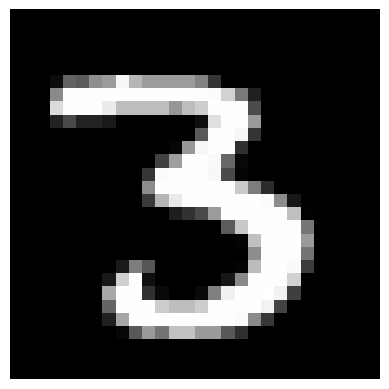

In [53]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load the MNIST dataset
(images_train, _), (_, _) = mnist.load_data()

# Select the 13th image from the training dataset (index 12)
image = np.array(images_train[12])

# Display the image in grayscale
plt.imshow(image, cmap='gray')
plt.axis('off')  # Optional: removes axis ticks
plt.show()

### Simple convolution animation ###

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Simulate a 28x28 grayscale image with random values resembling an MNIST digit


# Define the 3x3 convolution kernel (e.g., a simple edge detection kernel)
kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

# Function to apply zero-padding to the image
def zero_pad(image, pad_width):
    return np.pad(image, pad_width=pad_width, mode='constant', constant_values=0)

# Function to prepare animation with highlighted region on full image
def animate_convolution_with_progress(image, kernel):
    padded_image = zero_pad(image, pad_width=1)
    output = np.zeros_like(image)
    fig, ax = plt.subplots(3, 2, figsize=(10, 9), gridspec_kw={'height_ratios': [2, 1, 1]})
    
    # Full image display with highlighted region
    full_img = ax[0, 0].imshow(image, cmap='gray', vmin=0, vmax=255)
    highlight = plt.Rectangle((0, 0), 3, 3, edgecolor='red', facecolor='none', linewidth=2)
    ax[0, 0].add_patch(highlight)
    ax[0, 0].set_title("Full Image with Highlighted Region")
    ax[0, 0].axis('off')
    
    # Initialize plots for 3x3 region and convolution result
    region_img = ax[1, 0].imshow(np.zeros((3, 3)), cmap='gray', vmin=0, vmax=255)
    ax[1, 0].set_title("3x3 Region")
    ax[1, 0].axis('off')
    
    result_img = ax[2, 0].imshow(np.zeros((1, 1)), cmap='gray', vmin=-1020, vmax=1020)
    ax[2, 0].set_title("Convolution Result")
    ax[2, 0].axis('off')
    
    # Display for progressively built convoluted image
    conv_img_display = ax[0, 1].imshow(output, cmap='gray', vmin=-1020, vmax=1020)
    ax[0, 1].set_title("Convoluted Image (Progress)")
    ax[0, 1].axis('off')
    
    # Blank spaces for layout consistency
    ax[1, 1].axis('off')
    ax[2, 1].axis('off')
    
    # Generator to yield convolution steps
    def convolution_steps():
        for i in range(output.shape[0]):
            for j in range(output.shape[1]):
                # Extract the 3x3 region and calculate convolution
                region = padded_image[i:i+3, j:j+3]
                conv_result = np.sum(region * kernel)
                output[i, j] = conv_result
                yield region, conv_result, i, j

    # Update function for animation
    def update(frame):
        region, conv_result, i, j = frame
        region_img.set_array(region)
        result_img.set_array(np.array([[conv_result]]))
        highlight.set_xy((j - 1.5, i - 1.5))  # Adjust for padding
        
        # Update the convoluted image display
        conv_img_display.set_array(output)
        return full_img, highlight, region_img, result_img, conv_img_display

    # Create the animation with cache_frame_data set to False
    ani = animation.FuncAnimation(fig, update, frames=convolution_steps, blit=True, repeat=False, cache_frame_data=False)
    plt.close(fig)  # Prevent duplicate display in Jupyter
    return ani

# Create and display the animation with highlighted region
highlighted_convolution_animation = animate_convolution_with_progress(image, kernel)

# To display the animation in Jupyter, you can use:
# from IPython.display import HTML
# HTML(highlighted_convolution_animation.to_jshtml())

# Or to save as a GIF:
highlighted_convolution_animation.save("highlighted_convolution_animation.gif", writer="imagemagick")

MovieWriter imagemagick unavailable; using Pillow instead.


### ENOS counting ###

In [ ]:
import numpy as np

# Define the box blur kernel (3x3 averaging)
kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

# Function to apply zero-padding to the image
def zero_pad(image, pad_width):
    return np.pad(image, pad_width=pad_width, mode='constant', constant_values=0)

# Function to apply a 3x3 convolution operation
def apply_convolution(image, kernel):
    padded_image = zero_pad(image, pad_width=1)
    output = np.zeros_like(image, dtype=float)  # Use float to capture fractional values from box blur
    
    # Perform the convolution
    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            region = padded_image[i:i+3, j:j+3]
            output[i, j] = np.sum(region * kernel)
    
    return output

# Function to count light pixels along full 3x3 grids in each direction for ENOS protocol
def count_light_pixels(convoluted_image, i, j, threshold):
    counts = [0, 0, 0, 0]  # N, E, W, S
    NORD, EST, OUEST, SUD = 0, 1, 2, 3

    # Nord (Upwards) - Count light pixels along the column above the center
    for k in range(i - 1, -1, -1):  # Go upwards
        if convoluted_image[k, j] > threshold:
            counts[NORD] += 1
        else:
            break  # Stop counting if we hit a non-light pixel

    # Est (Rightwards) - Count light pixels along the row to the right of the center
    for k in range(j + 1, convoluted_image.shape[1]):  # Go rightwards
        if convoluted_image[i, k] > threshold:
            counts[EST] += 1
        else:
            break

    # Ouest (Leftwards) - Count light pixels along the row to the left of the center
    for k in range(j - 1, -1, -1):  # Go leftwards
        if convoluted_image[i, k] > threshold:
            counts[OUEST] += 1
        else:
            break

    # Sud (Downwards) - Count light pixels along the column below the center
    for k in range(i + 1, convoluted_image.shape[0]):  # Go downwards
        if convoluted_image[k, j] > threshold:
            counts[SUD] += 1
        else:
            break

    return counts

# Main function to apply the ENOS protocol
def apply_enos_protocol(image, kernel, threshold=127):
    # Step 1: Apply convolution to the image
    convoluted_image = apply_convolution(image, kernel)
    
    # Inspect convoluted image values for choosing an effective threshold
    print("Sample convoluted image values:")
    print(convoluted_image[:5, :5])  # Show a small sample of values for inspection

    # Step 2: Initialize ENOS count storage
    enos_counts = np.zeros((convoluted_image.shape[0], convoluted_image.shape[1], 4), dtype=int)
    
    # Step 3: Apply ENOS protocol over the convoluted image
    for i in range(1, convoluted_image.shape[0] - 1):
        for j in range(1, convoluted_image.shape[1] - 1):
            enos_counts[i, j] = count_light_pixels(convoluted_image, i, j, threshold)
    
    return convoluted_image, enos_counts

# Example usage
# Assuming `image` is your input grayscale image (e.g., a 28x28 MNIST digit)
np.random.seed(0)  # Example image
image = np.random.randint(0, 256, (28, 28))

# Apply ENOS protocol to the image with box blur and specified threshold
convoluted_image, enos_counts = apply_enos_protocol(image, kernel, threshold=100)  # Adjust threshold as needed based on output

# Display ENOS counts to verify
print("ENOS Counts (Sample):")
print(enos_counts[:5, :5, :])  # Show a sample of ENOS counts for inspection

### ENOS Animation ###

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Define the box blur kernel (3x3 averaging)
kernel = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
])

threshold = 100  # Threshold for light pixels

# Function to apply zero-padding to the image
def zero_pad(image, pad_width):
    return np.pad(image, pad_width=pad_width, mode='constant', constant_values=0)

# Function to apply a 3x3 convolution operation
def apply_convolution(image, kernel):
    padded_image = zero_pad(image, pad_width=1)
    output = np.zeros_like(image, dtype=float)  # Use float to capture fractional values from box blur
    
    # Perform the convolution
    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            region = padded_image[i:i+3, j:j+3]
            output[i, j] = np.sum(region * kernel)
    
    return output

# Function to count and return light pixels along a specific direction for visualization
def highlight_direction(convoluted_image, i, j, direction, threshold):
    # Start with no highlighted pixels
    highlighted_pixels = np.zeros_like(convoluted_image, dtype=int)
    light_pixels = 0

    if direction == 'N':
        for k in range(i - 1, -1, -1):  # Go upwards
            if convoluted_image[k, j] > threshold:
                highlighted_pixels[k, j] = 1
                light_pixels += 1
    elif direction == 'E':
        for k in range(j + 1, convoluted_image.shape[1]):  # Go rightwards
            if convoluted_image[i, k] > threshold:
                highlighted_pixels[i, k] = 1
                light_pixels += 1
    elif direction == 'W':
        for k in range(j - 1, -1, -1):  # Go leftwards
            if convoluted_image[i, k] > threshold:
                highlighted_pixels[i, k] = 1
                light_pixels += 1
    elif direction == 'S':
        for k in range(i + 1, convoluted_image.shape[0]):  # Go downwards
            if convoluted_image[k, j] > threshold:
                highlighted_pixels[k, j] = 1
                light_pixels += 1

    return highlighted_pixels, light_pixels

# Function to animate the ENOS protocol
def animate_enos(convoluted_image, random_points, threshold):
    fig, ax = plt.subplots(figsize=(6, 6))
    image_display = ax.imshow(convoluted_image, cmap='gray', vmin=0, vmax=255)
    ax.axis('off')
    
    # Rectangle to highlight the 3x3 grid
    highlight = plt.Rectangle((0, 0), 3, 3, edgecolor='red', facecolor='none', linewidth=2)
    ax.add_patch(highlight)

    # Text to show the current direction and count of light pixels
    direction_text = ax.text(0.5, 1.05, "", ha="center", fontsize=12, color="blue", weight="bold", transform=ax.transAxes)

    # Variables to track the current grid
    current_grid = [-1, -1]  # Initialize to an impossible grid position
    
    # Update function for the animation
    def update(frame):
        i, j, direction = frame
        
        # Reset the image to the original convoluted image when switching to a new grid
        if [i, j] != current_grid:
            current_grid[0], current_grid[1] = i, j
            image_display.set_data(convoluted_image)  # Reset to the base image
            highlight.set_xy((j - 1.5, i - 1.5))  # Update grid highlight position
        
        # Get highlighted pixels and count for the current direction
        highlighted_pixels, light_pixel_count = highlight_direction(convoluted_image, i, j, direction, threshold)
        
        # Update the image display to show highlighted pixels with magma colormap
        masked_image = np.ma.masked_array(convoluted_image, mask=~highlighted_pixels.astype(bool))
        ax.imshow(masked_image, cmap='magma', alpha=0.7)
        
        # Update the direction and count text
        direction_text.set_text(f"Direction: {direction}, Light Pixels: {light_pixel_count}")

        return image_display, highlight, direction_text

    # Define the frames (random points and directions for each step)
    directions = ['N', 'E', 'W', 'S']
    frames = [(i, j, dir) for i, j in random_points for dir in directions]

    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=frames, blit=True, repeat=False, interval=500)
    plt.close(fig)
    return ani

# Example usage
# Generate a sample convoluted image

image = np.array(images_train[12])
convoluted_image = apply_convolution(image, kernel)

# Select random points for the animation
# To ensure reproducibility
random_points = [(np.random.randint(1, convoluted_image.shape[0] - 1),
                  np.random.randint(1, convoluted_image.shape[1] - 1)) for _ in range(5)]

# Create and display the animation
enos_animation = animate_enos(convoluted_image, random_points, threshold)

# To display the animation in a Jupyter notebook:
# from IPython.display import HTML
# HTML(enos_animation.to_jshtml())

# Or to save as a GIF:
#enos_animation.save("enos_protocol_animation.gif", writer="imagemagick")

MovieWriter imagemagick unavailable; using Pillow instead.


In [68]:
image = np.array(images_train[12])
convoluted_image = apply_convolution(image, kernel)
for i in range(5):
    random_points = [(np.random.randint(1, convoluted_image.shape[0] - 1),
                    np.random.randint(1, convoluted_image.shape[1] - 1)) ]

    # Create and display the animation
    enos_animation = animate_enos(convoluted_image, random_points, threshold)
    enos_animation.save(f"enos_protocol_animation{i}.gif", writer="imagemagick")

MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.


In [72]:
from PIL import Image

# List of file paths for GIFs you want to combine
gif_files = ["enos_protocol_animation0.gif", "enos_protocol_animation1.gif", "enos_protocol_animation2.gif", "enos_protocol_animation3.gif", "enos_protocol_animation4.gif"]

# Load the frames of each GIF
gif_frames = [Image.open(gif) for gif in gif_files]

# Combine all frames into a new GIF
combined_gif_path = "COMBINED_enos_protocol_animation1.gif"
gif_frames[0].save(
    combined_gif_path,
    save_all=True,
    append_images=gif_frames[1:],  # Append all other GIF frames
    duration=800,  # Duration for each frame in milliseconds
    loop=0  
)